# Dimensionality Reduction

## Objective

In this notebook, we will practice:

- Principal Component Analysis (PCA)
- Linear Discriminant Analysis (LDA)
- t-SNE
- UMAP
- Autoencoder

The original Heart Failure dataset will remain unchanged.

> A random `practice_target` will be used only to demonstrate LDA.
> It does not represent a real medical outcome.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

In [2]:
df = pd.read_csv(
    "../heart_failure_clinical_records_dataset-selected-columns.csv"
)

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
0,75.0,0,582,0,20,1,265000.00,1.9,130,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0


In [3]:
numerical_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

X = df[numerical_features].copy()

print("Original Shape:", X.shape)

Original Shape: (299, 6)


# Principal Component Analysis (PCA)

PCA combines information from multiple numerical features into fewer Principal Components.

PCA does not require a target variable.

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
0,1.192945,0.000166,-1.530560,1.681648e-02,0.490057,-1.504036
1,-0.491279,7.514640,-0.007077,7.535660e-09,-0.284552,-0.141976
2,0.350833,-0.449939,-1.530560,-1.038073e+00,-0.090900,-1.731046
3,-0.912335,-0.486071,-1.530560,-5.464741e-01,0.490057,0.085034
4,0.350833,-0.435486,-1.530560,6.517986e-01,1.264666,-4.682176


In [5]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-2.034853,-0.672180
1,1.757645,-3.197428
2,-1.943501,-1.260288
3,-0.583394,-1.277827
4,-3.904474,-1.573671


In [6]:
print("Before PCA:", X_scaled.shape)
print("After PCA:", pca_df.shape)

Before PCA: (299, 6)
After PCA: (299, 2)


In [7]:
explained_variance = (
    pca.explained_variance_ratio_
)

print(
    "PC1 Explained Variance:",
    round(explained_variance[0] * 100, 2),
    "%"
)

print(
    "PC2 Explained Variance:",
    round(explained_variance[1] * 100, 2),
    "%"
)

print(
    "Total Explained Variance:",
    round(explained_variance.sum() * 100, 2),
    "%"
)

PC1 Explained Variance: 22.42 %
PC2 Explained Variance: 19.23 %
Total Explained Variance: 41.65 %


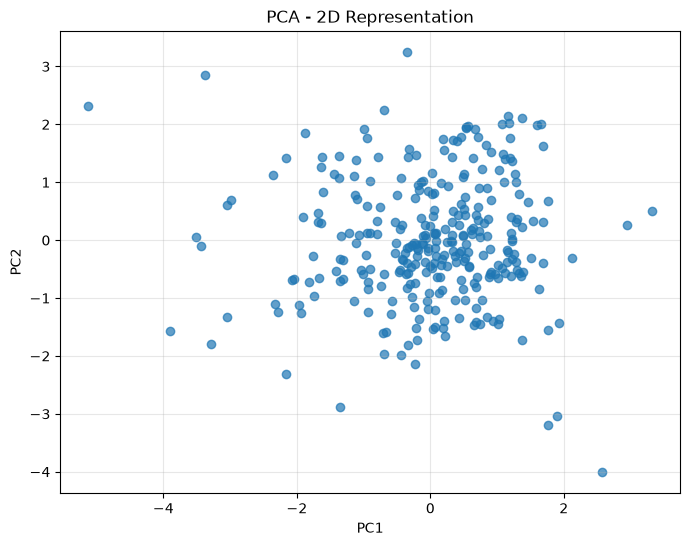

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - 2D Representation")
plt.grid(alpha=0.3)

plt.show()

# Linear Discriminant Analysis (LDA)

LDA is supervised.

It requires a target variable and tries to create dimensions that separate classes.

A random target is used here only for learning the workflow.

In [9]:
np.random.seed(42)

practice_target = np.random.randint(
    0,
    2,
    size=len(X_scaled)
)

print(
    pd.Series(
        practice_target
    ).value_counts()
)

0    151
1    148
Name: count, dtype: int64


In [10]:
lda = LinearDiscriminantAnalysis(
    n_components=1
)

X_lda = lda.fit_transform(
    X_scaled,
    practice_target
)

lda_df = pd.DataFrame({
    "LD1": X_lda.flatten(),
    "Practice Target": practice_target
})

lda_df.head()

,LD1,Practice Target
0,-0.942255,0
1,-3.235473,1
2,-0.930896,0
3,-0.338831,0
4,-2.380578,0


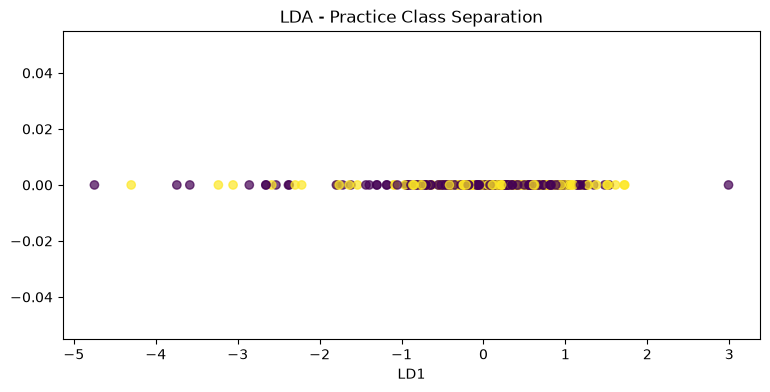

In [11]:
plt.figure(figsize=(9, 4))

plt.scatter(
    lda_df["LD1"],
    np.zeros(len(lda_df)),
    c=lda_df["Practice Target"],
    alpha=0.7
)

plt.xlabel("LD1")
plt.title("LDA - Practice Class Separation")

plt.show()

# t-SNE

t-SNE converts high-dimensional data into a low-dimensional representation.

It is mainly useful for visualization and exploring local clusters.

In [12]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(
    X_scaled
)

tsne_df = pd.DataFrame(
    X_tsne,
    columns=["tSNE1", "tSNE2"]
)

tsne_df.head()

,tSNE1,tSNE2
0,0.219102,10.603458
1,17.352388,13.712290
2,3.753972,10.797373
3,7.367854,4.699564
4,16.563860,2.334844


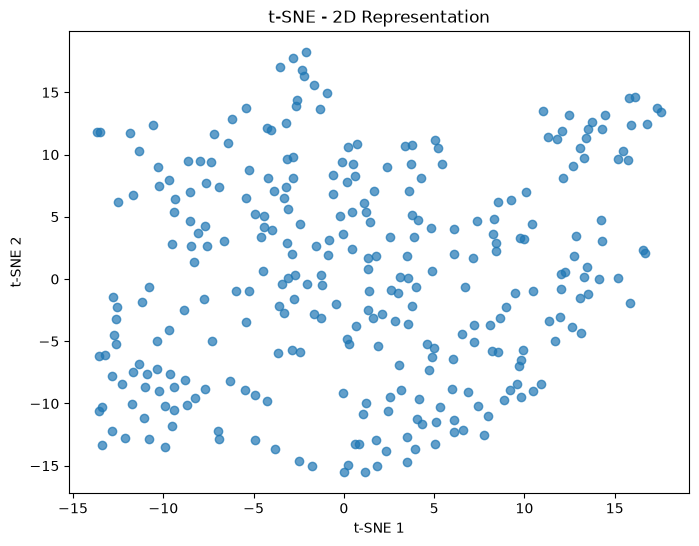

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    tsne_df["tSNE1"],
    tsne_df["tSNE2"],
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE - 2D Representation")

plt.show()

# UMAP

UMAP is another nonlinear dimensionality reduction technique.

It is commonly used for high-dimensional visualization and low-dimensional representation.

In [14]:
import umap

In [15]:
umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(
    X_scaled
)

umap_df = pd.DataFrame(
    X_umap,
    columns=["UMAP1", "UMAP2"]
)

umap_df.head()

f:\machine-learning-beginner-to-advanced\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP1,UMAP2
0,5.294116,9.689252
1,1.467933,6.791124
2,4.515853,9.707628
3,3.743560,8.055417
4,4.010551,9.883983


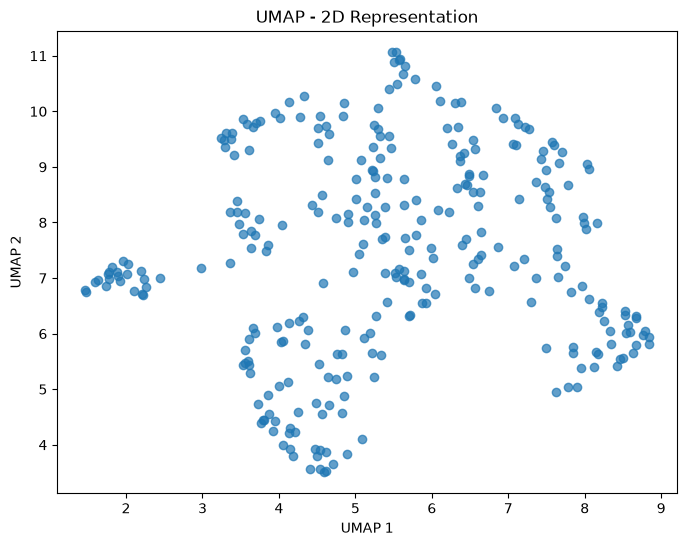

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    umap_df["UMAP1"],
    umap_df["UMAP2"],
    alpha=0.7
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP - 2D Representation")

plt.show()

# Autoencoder

An Autoencoder is a Neural Network that learns a compressed representation of the input.

Flow:

Input → Encoder → Latent Representation → Decoder → Reconstruction

In [25]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense
)

In [18]:
input_size = X_scaled.shape[1]

input_layer = Input(
    shape=(input_size,)
)

encoded = Dense(
    3,
    activation="relu",
    name="compressed_layer"
)(input_layer)

decoded = Dense(
    input_size,
    activation="linear"
)(encoded)

autoencoder = Model(
    inputs=input_layer,
    outputs=decoded
)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compressed_layer (Dense)        │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            24 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45 (180.00 B)

 Trainable params: 45 (180.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=50,
    batch_size=32,
    verbose=0
)

print("Autoencoder Training Complete")

Autoencoder Training Complete


In [20]:
encoder = Model(
    inputs=input_layer,
    outputs=encoded
)

compressed_data = encoder.predict(
    X_scaled,
    verbose=0
)

compressed_df = pd.DataFrame(
    compressed_data,
    columns=[
        "Latent1",
        "Latent2",
        "Latent3"
    ]
)

compressed_df.head()

,Latent1,Latent2,Latent3
0,1.562475,0.412683,1.407928
1,0.746423,4.559644,1.297172
2,1.571158,0.432176,1.135307
3,0.552263,0.000000,0.327700
4,1.754122,0.000000,2.821100


In [21]:
print(
    "Original Dimensions:",
    X_scaled.shape
)

print(
    "Compressed Dimensions:",
    compressed_df.shape
)

Original Dimensions: (299, 6)
Compressed Dimensions: (299, 3)


In [22]:
reconstructed_data = autoencoder.predict(
    X_scaled,
    verbose=0
)

reconstructed_df = pd.DataFrame(
    reconstructed_data,
    columns=X.columns
)

reconstructed_df.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
0,0.506430,0.060978,0.055441,-0.323207,1.203732,-0.291322
1,1.631797,3.585919,1.694843,-0.830321,-0.826516,-2.111923
2,0.503388,-0.037408,-0.050428,-0.488698,0.996695,-0.091283
3,-0.029948,-0.264702,-0.189174,-0.069538,0.182763,0.149610
4,0.497289,0.228070,0.420243,0.436376,2.489516,-1.096666


In [23]:
dimension_comparison = pd.DataFrame({
    "Technique": [
        "Original Data",
        "PCA",
        "LDA",
        "t-SNE",
        "UMAP",
        "Autoencoder"
    ],
    "Dimensions": [
        X.shape[1],
        pca_df.shape[1],
        1,
        tsne_df.shape[1],
        umap_df.shape[1],
        compressed_df.shape[1]
    ]
})

dimension_comparison

,Technique,Dimensions
0,Original Data,6
1,PCA,2
2,LDA,1
3,t-SNE,2
4,UMAP,2
5,Autoencoder,3


In [24]:
print("Original Shape:", df.shape)

print(
    "Original Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Original Columns:",
    df.columns.tolist()
)

Original Shape: (299, 10)
Original Missing Values: 0
Original Columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex']


# Summary

In this notebook, we practiced:

- Principal Component Analysis (PCA)
- Linear Discriminant Analysis (LDA)
- t-SNE
- UMAP
- Autoencoders

## Key Learnings

- PCA reduces dimensions without using a target.
- LDA uses target classes to create better class separation.
- t-SNE is mainly useful for high-dimensional visualization.
- UMAP provides another low-dimensional representation.
- Autoencoders use Neural Networks to learn compressed representations.
- Dimensionality Reduction creates new representations rather than simply selecting original features.
- Reduced representations may lose some original information.
- The original dataset should remain unchanged during experimentation.